<a href="https://colab.research.google.com/github/lack-of-sleep/2609Study/blob/main/06-12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 06**

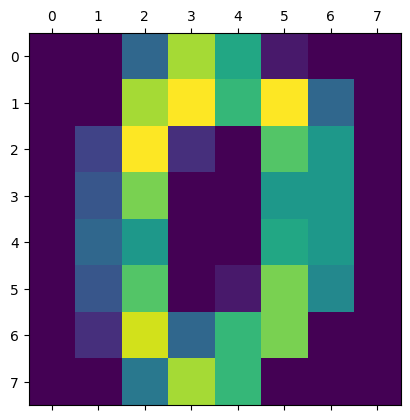

In [2]:
from sklearn.datasets import load_digits
#sklearn 라이브러리 datasets에서 이미지를 숫자화 시킨 데이터(digits) load
import matplotlib.pyplot as plt
#matplolib는 그래프 시각화 라이브러리의 pyplot 모듈을 가져옴 이 명령어를 plt라고 별칭
digit=load_digits()
#digit에 로드한 숫자데이터셋 저장
digit.images[0]
#digit에 있는 이미지 배열에서 첫번째 이미지 데이터를 가져옴(출력x)
plt.matshow(digit.images[0])
#행렬 형태 시각화, 값 크기에 따라 색상이 다름
plt.show()
#그래프 출력

In [3]:
dir(digit)
#digit가 가지고 있는 요소들 출력

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

In [4]:
type(digit.images)

numpy.ndarray

In [5]:
type(digit.data)

numpy.ndarray

In [6]:
digit.data.shape
#64개의 픽셀이 있음(1차원)

(1797, 64)

In [7]:
digit.images.shape
#8x8의 픽셀이 있음(2차원)

(1797, 8, 8)

In [8]:
a = digit.data.reshape(1797,8,8)
b = digit.images

import numpy as np
np.allclose(a,b)
#allclose = 두 배열의 요소가 같은지 비교

True

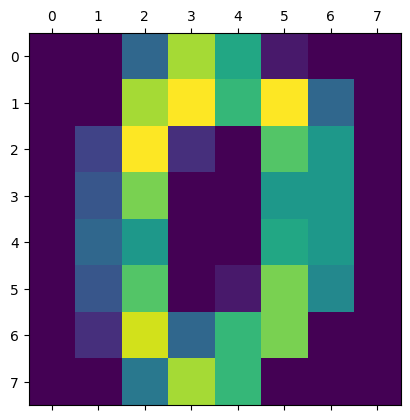

In [9]:
plt.matshow(digit.data.reshape(1797,8,8)[0])
#digit.data.reshape(1797,8,8) = digit.images 라서 결과값이 같음
plt.show()

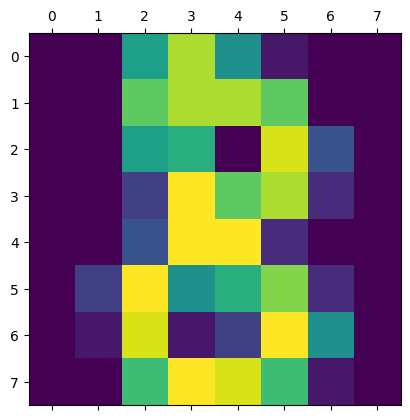

In [10]:
plt.matshow(digit.images[8])
plt.show()

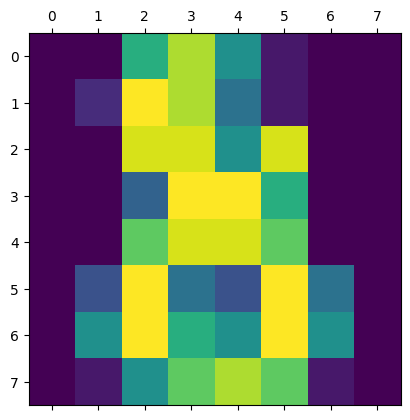

In [11]:
plt.matshow(digit.images[1796])
#마지막 인덱스 요소 출력
plt.show()
#6인지 8인지 모르겠다

In [12]:
digit.target[1796]
#마지막 요소는 8

np.int64(8)

In [13]:
digit.target[-1]
#1796 배열이 마지막인지 확인차 다시 마지막(-1)요소를 확인

np.int64(8)

# **Section 07**

In [14]:
import torch.nn as nn
#파이토치(torch) 신경망(nn) import

#신경망 정의
class SimpleNN(nn.Module):
  #SimpleNN이라는 클래스 생성하고 신경망의 모듈 상속
    def __init__(self,input_size, output_size):
      #신경망 초기화 메소드(생성자)
      #자기자신, 입력사이즈(1차원 64픽셀), 출력사이즈(0-9까지의 숫자종류)를 인자로 받음
        super(SimpleNN, self).__init__()
        #SimpleNN의 부모클래스 nn.Module 본인호출, 그걸 초기화 메소드로 실행
        self.fc = nn.Linear(input_size, output_size)
        #fc는 전결합층 신경망(Fully Connected)
        #input_size 입력->output_size 출력한 선형레이어를 생성->self.fc에 변수저장

    def forward(self, x):
      #순방향 전파 메소드
        out = self.fc(x)
        #fc 레이어에 입력데이터(x)를 넣어 결과(out)를 계산
        return out
        #out 반환

1층 전결합형 신경망은
8x8=64 픽셀 데이터가 1차원으로 평면화되어 있음

# **Section 08**

In [15]:
digit.data.shape

(1797, 64)

In [16]:
import numpy as np
import torch

x = torch.tensor(np.random.rand(64), dtype=torch.float32)
#64차원의 랜덤배열 생성->tensor 형식으로 변환, 데이터 타입은 32비트 실수형(float32)으로

print(x.shape)
print(x.dtype)

torch.Size([64])
torch.float32


In [17]:
model = SimpleNN(64,10)
#(입력차원,출력차원)
model

SimpleNN(
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [18]:
y = model.forward(x)
y

tensor([ 0.0435, -0.0294, -0.2958,  0.0281, -0.6998, -0.6447, -0.3610,  0.6029,
        -0.1586,  0.1388], grad_fn=<ViewBackward0>)

In [19]:
print(torch.argmax(model.forward(x)).item())
#현재 텐서에서 값이 큰 위치의 인덱스 반환(확률이 높은쪽)
#.item() 텐서 형태 결과값을 숫자로 추출

7


# **Section 09**
학습 전, 데이터 추론 시키기

In [20]:
digit.data[0]
#0번 데이터

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [21]:
digit.target[0]

np.int64(0)

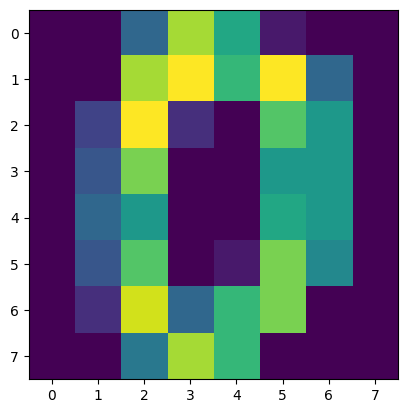

In [22]:
import matplotlib.pyplot as plt
plt.imshow(digit.images[0])
#함수를 이미지로 표시

In [23]:
digit.data[0].shape
#이제 이걸 64차원으로 구성된 SimpleNN(64,10)에 입력해야하는데 그전에 data의 차원확인

(64,)

In [24]:
digit.data[0].dtype
#타입이 float64 인데 이걸 torch.float32로 변형(캐스트)해야함

dtype('float64')

In [25]:
x0 = torch.tensor(digit.data[0], dtype=torch.float32)
print(x0.dtype)
#0번째 데이터를 float32로 캐스트해서 x0에 저장

torch.float32


In [26]:
torch.argmax(model(x0)).item()
#모델을 학습시키지 않았기 때문에 오답이 나온다
#정답은 0

7

In [27]:
x1 = torch.tensor(digit.data[1], dtype=torch.float32)
print(f"answer: {digit.target[1]}")
print(f"predicted: {torch.argmax(model(x1)).item()}")
#1번째 데이터도 오답

answer: 1
predicted: 7


# **Section 10**
전처리, 데이터 정규화

In [28]:
from sklearn.preprocessing import StandardScaler
x= digit.data
#학습데이터
y= digit.target
#정답데이터

scaler = StandardScaler()
#standardscaler로 정규화, 평균0, 표준편차1로 변환
X_scaler = scaler.fit_transform(x)
X_scaler
#정규화한 데이터를 X_scaler에 넣음

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

**x_norm = (x - μ)/σ**

μ는 각 열의 평균값
σ는 각 열의 표준편차



---



정규화

+)데이터 스케일을 통일하면 모델학습 안정적

+)서로 다른 척도의 데이터 비교 수월


-)이상값 영향 받기 쉬움, 이상값 처리 미리

-)정규화 후 데이터 해석 주의(원본과 스케일이 다름)


# **Section 11**

학습8:테스트2 비율로 데이터 분할

In [31]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X_scaler, y, test_size=0.2, random_state=66)
#x 추측, y 정답
#X_scaler 정규화 데이터
#test비율 0.2로 설정, 랜덤배정

print(len(x_train))
print(len(x_test))
print(len(x_test)/(len(x_train)+len(x_test)))

1437
360
0.2003338898163606


# **Section12**
모델 신경망 학습


손실 함수 : 교차 엔트로피 손실

최적화 함수 : 확률적 경사하강법(SGD)

In [32]:
import torch.optim as optim

#파이토치 텐서로 변환
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
#float32(실수형) 로 변환

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)
#long(정수형) 로 변환

#손실 함수 및 최적화 기법 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

#모델학습
num_epochs = 100
for epoch in range(num_epochs):
  optimizer.zero_grad() #기울기 초기화
  outputs = model(x_train) #현재 모델의 값 예측
  loss = criterion(outputs, y_train) #예측값과 정답 비교해 오차(손실) 계산
  loss.backward() #손실기반으로 가중치 수정값 계산(오차 역전파)
  optimizer.step() #가중치 epoch(=100) 값만큼 업데이트

  if (epoch+1) % 10 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

#loss 값이 줄어들었다



Epoch [10/100], Loss: 2.4443
Epoch [20/100], Loss: 2.2533
Epoch [30/100], Loss: 2.0800
Epoch [40/100], Loss: 1.9237
Epoch [50/100], Loss: 1.7836
Epoch [60/100], Loss: 1.6586
Epoch [70/100], Loss: 1.5473
Epoch [80/100], Loss: 1.4484
Epoch [90/100], Loss: 1.3605
Epoch [100/100], Loss: 1.2822
